<a href="https://colab.research.google.com/github/Fabiouxd/projeto-cardioIA-fase4/blob/main/parte2_cnn_transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CardioIA — Fase 4
## Parte 2: Classificacao de Imagens Medicas com CNN

**Disciplina:** Inteligencia Artificial e Visao Computacional  
**Instituicao:** FIAP  
**Dataset:** Chest X-Ray Images (Pneumonia) — Kaggle  
**Integrantes:**
- Bernardo Rupolo
- Fabio Mendes
- Leonardo Magalhaes
- Marcos Vinicius dos Santos Morgado

---

Este notebook implementa duas abordagens de classificacao de imagens medicas:

1. **CNN treinada do zero** — arquitetura simples construida com Keras
2. **Transfer Learning com VGG16** — modelo pre-treinado no ImageNet com fine-tuning

Ao final, os resultados sao comparados por meio de metricas de avaliacao e apresentados em um prototipo interativo simples.

## 1. Instalacoes e Importacoes

In [1]:
!pip install kaggle -q

In [2]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU disponivel:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU disponivel: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download e Preparacao do Dataset

Caso ja tenha executado a Parte 1 nesta mesma sessao do Colab, o dataset ja esta disponivel em `/content/data/`. Caso contrario, execute as celulas abaixo para baixar novamente.

In [3]:
import os

KAGGLE_TOKEN = 'KGAT_3e13af07d1a807ed002d1287a1579f36'
KAGGLE_USERNAME = 'fabiocmmc'

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

kaggle_json = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_TOKEN
}

import json as _json
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    _json.dump(kaggle_json, f)

os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print('Autenticacao configurada com sucesso.')

Autenticacao configurada com sucesso.


## 3. Geradores de Dados

Sao utilizados geradores do Keras para carregar as imagens em lotes (batches) diretamente do disco, com aumento de dados (data augmentation) aplicado ao conjunto de treino para reduzir o overfitting e compensar o desbalanceamento entre classes.

In [9]:
import shutil
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR = '/content/data/chest_xray'
DRIVE_DATASET_DIR = '/content/drive/MyDrive/cardioIA_dataset/chest_xray/chest_xray'

if os.path.exists(DRIVE_DATASET_DIR):
    print('Dataset encontrado no Drive. Copiando...')
    if not os.path.exists(BASE_DIR):
        shutil.copytree(DRIVE_DATASET_DIR, BASE_DIR)
    print('Pronto.')
else:
    print('Dataset nao encontrado no Drive. Execute a Parte 1 primeiro.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset encontrado no Drive. Copiando...
Pronto.


In [8]:
import os

# Verificar estrutura do Drive
drive_path = '/content/drive/MyDrive/cardioIA_dataset'
if os.path.exists(drive_path):
    for root, dirs, files in os.walk(drive_path):
        level = root.replace(drive_path, '').count(os.sep)
        if level < 3:
            print(root)
else:
    print('Pasta cardioIA_dataset nao encontrada no Drive')

/content/drive/MyDrive/cardioIA_dataset
/content/drive/MyDrive/cardioIA_dataset/chest_xray
/content/drive/MyDrive/cardioIA_dataset/chest_xray/chest_xray
/content/drive/MyDrive/cardioIA_dataset/chest_xray/test
/content/drive/MyDrive/cardioIA_dataset/chest_xray/val
/content/drive/MyDrive/cardioIA_dataset/chest_xray/__MACOSX


In [17]:
import os

# Verificar o que esta em /content/data
if os.path.exists('/content/data'):
    for root, dirs, files in os.walk('/content/data'):
        level = root.replace('/content/data', '').count(os.sep)
        if level < 4:
            print(root)
else:
    print('Pasta /content/data nao existe')

/content/data
/content/data/chest_xray
/content/data/chest_xray/val
/content/data/chest_xray/val/PNEUMONIA
/content/data/chest_xray/val/NORMAL
/content/data/chest_xray/__MACOSX
/content/data/chest_xray/__MACOSX/chest_xray
/content/data/chest_xray/test
/content/data/chest_xray/test/PNEUMONIA
/content/data/chest_xray/test/NORMAL
/content/data/chest_xray/chest_xray


In [18]:
import shutil
import os

# Mover conteudo da pasta duplicada para o lugar certo
src = '/content/data/chest_xray/chest_xray'
dst = '/content/data/chest_xray'

for item in os.listdir(src):
    s = os.path.join(src, item)
    d = os.path.join(dst, item)
    if not os.path.exists(d):
        shutil.move(s, d)

print('Corrigido. Verificando...')
for item in os.listdir(dst):
    print(item)

# Verificar estrutura completa
for root, dirs, files in os.walk('/content/data/chest_xray/chest_xray'):
    print(root)

Corrigido. Verificando...
val
__MACOSX
test
chest_xray
/content/data/chest_xray/chest_xray


In [19]:
import os

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/data_novo/ --unzip

# Verificar estrutura
for root, dirs, files in os.walk('/content/data_novo'):
    level = root.replace('/content/data_novo', '').count(os.sep)
    if level < 4:
        print(root)

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:18<00:00, 131MB/s]

/content/data_novo
/content/data_novo/chest_xray
/content/data_novo/chest_xray/val
/content/data_novo/chest_xray/val/PNEUMONIA
/content/data_novo/chest_xray/val/NORMAL
/content/data_novo/chest_xray/__MACOSX
/content/data_novo/chest_xray/__MACOSX/chest_xray
/content/data_novo/chest_xray/test
/content/data_novo/chest_xray/test/PNEUMONIA
/content/data_novo/chest_xray/test/NORMAL
/content/data_novo/chest_xray/chest_xray
/content/data_novo/chest_xray/chest_xray/val
/content/data_novo/chest_xray/chest_xray/test
/content/data_novo/chest_xray/chest_xray/train
/content/data_novo/chest_xray/train
/content/data_novo/chest_xray/train/PNEUMONIA
/content/data_novo/chest_xray/train/NORMAL


In [20]:
BASE_DIR = '/content/data_novo/chest_xray'
print('BASE_DIR definido:', BASE_DIR)
print(os.listdir(BASE_DIR))

BASE_DIR definido: /content/data_novo/chest_xray
['val', '__MACOSX', 'test', 'chest_xray', 'train']


In [21]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASSES = ['NORMAL', 'PNEUMONIA']

# Gerador de treino com augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Geradores de validacao e teste — apenas normalizacao
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(BASE_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(BASE_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=SEED
)

print('Mapeamento de classes:', train_gen.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Mapeamento de classes: {'NORMAL': 0, 'PNEUMONIA': 1}


## 4. Abordagem 1 — CNN Treinada do Zero

A arquitetura foi definida com tres blocos convolucionais seguidos de camadas densas. Cada bloco contem uma camada Conv2D com ativacao ReLU, uma camada de MaxPooling e Dropout para regularizacao.

In [22]:
def criar_cnn_do_zero(input_shape=(224, 224, 3)):
    model = models.Sequential([
        # Bloco 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Bloco 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Bloco 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Classificador
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

cnn_zero = criar_cnn_do_zero()
cnn_zero.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
cnn_zero.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,783,873 (98.36 MB)

 Trainable params: 25,783,873 (98.36 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
callbacks_zero = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')
]

history_zero = cnn_zero.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks_zero
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 124s 697ms/step - accuracy: 0.7814 - loss: 0.5638 - val_accuracy: 0.6250 - val_loss: 0.6265 - learning_rate: 0.0010
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 673ms/step - accuracy: 0.8863 - loss: 0.2758 - val_accuracy: 0.7500 - val_loss: 0.7067 - learning_rate: 0.0010
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 662ms/step - accuracy: 0.9020 - loss: 0.2385 - val_accuracy: 0.7500 - val_loss: 0.4228 - learning_rate: 0.0010
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 680ms/step - accuracy: 0.9155 - loss: 0.2153 - val_accuracy: 0.8125 - val_loss: 0.5791 - learning_rate: 0.0010
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 688ms/step - accuracy: 0.9156 - loss: 0.2129 - val_accuracy: 0.7500 - val_loss: 0.4250 - learning_rate: 0.0010
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 660ms/step - accuracy: 0.9264 - loss: 0.1915 - val_accuracy: 0.8750 - val_loss: 0.3108 - learning_rate: 0.0010
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 692ms/step - accura

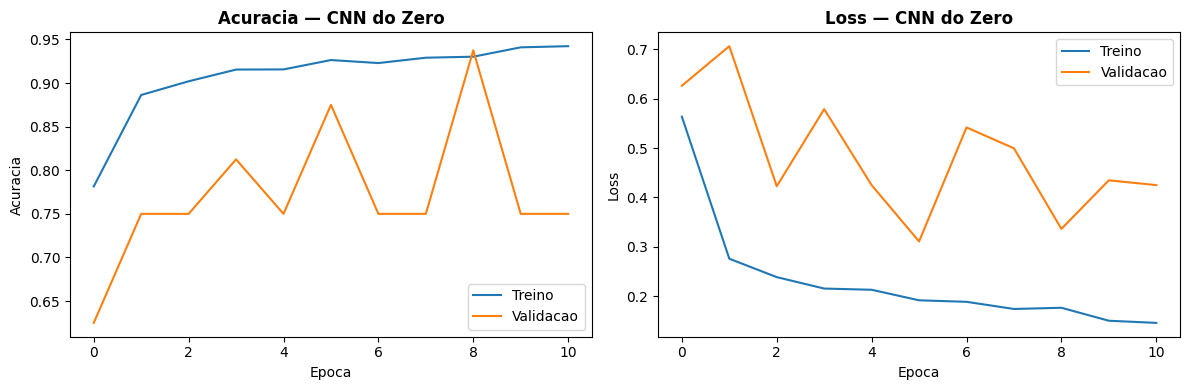

In [24]:
# Curvas de treinamento — CNN do zero
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_zero.history['accuracy'], label='Treino')
axes[0].plot(history_zero.history['val_accuracy'], label='Validacao')
axes[0].set_title('Acuracia — CNN do Zero', fontweight='bold')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Acuracia')
axes[0].legend()

axes[1].plot(history_zero.history['loss'], label='Treino')
axes[1].plot(history_zero.history['val_loss'], label='Validacao')
axes[1].set_title('Loss — CNN do Zero', fontweight='bold')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/curvas_cnn_zero.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Abordagem 2 — Transfer Learning com VGG16

O VGG16 foi pre-treinado no dataset ImageNet (mais de 1 milhao de imagens, 1000 classes). Nesta abordagem, as camadas convolucionais do VGG16 sao utilizadas como extratores de features fixos, e apenas as camadas densas adicionadas ao topo sao treinadas. Isso permite aproveitar representacoes visuais ricas ja aprendidas pelo modelo, mesmo com um dataset menor.

In [25]:
def criar_modelo_vgg16(input_shape=(224, 224, 3)):
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    # Congelar camadas da base
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

modelo_vgg = criar_modelo_vgg16()
modelo_vgg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
modelo_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [26]:
callbacks_vgg = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')
]

history_vgg = modelo_vgg.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks_vgg
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 142s 772ms/step - accuracy: 0.7366 - loss: 0.5471 - val_accuracy: 0.5000 - val_loss: 0.7100 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 706ms/step - accuracy: 0.7989 - loss: 0.4126 - val_accuracy: 0.5625 - val_loss: 0.6819 - learning_rate: 1.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 704ms/step - accuracy: 0.8493 - loss: 0.3485 - val_accuracy: 0.6875 - val_loss: 0.5793 - learning_rate: 1.0000e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 140s 693ms/step - accuracy: 0.8706 - loss: 0.3042 - val_accuracy: 0.7500 - val_loss: 0.5729 - learning_rate: 1.0000e-04
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 701ms/step - accuracy: 0.8886 - loss: 0.2759 - val_accuracy: 0.6875 - val_loss: 0.6417 - learning_rate: 1.0000e-04
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 700ms/step - accuracy: 0.8986 - loss: 0.2577 - val_accuracy: 0.7500 - val_loss: 0.6058 - learning_rate: 1.0000e-04
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 

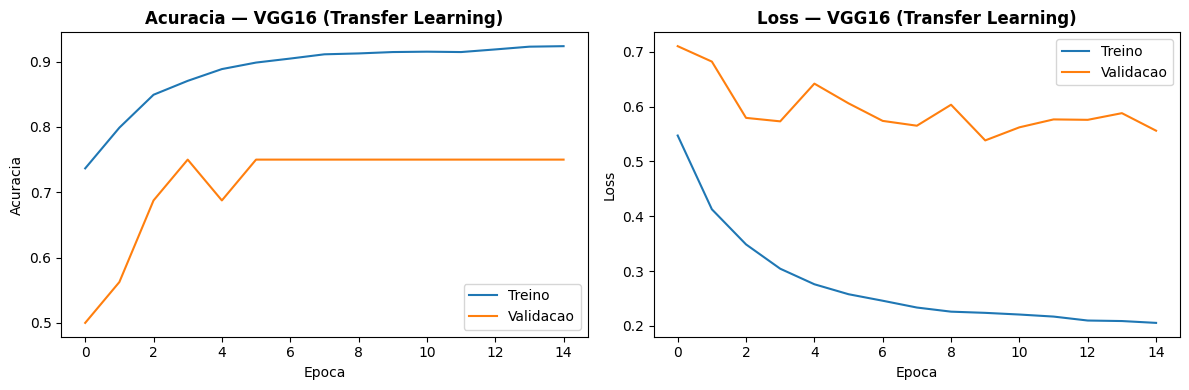

In [27]:
# Curvas de treinamento — VGG16
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_vgg.history['accuracy'], label='Treino')
axes[0].plot(history_vgg.history['val_accuracy'], label='Validacao')
axes[0].set_title('Acuracia — VGG16 (Transfer Learning)', fontweight='bold')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Acuracia')
axes[0].legend()

axes[1].plot(history_vgg.history['loss'], label='Treino')
axes[1].plot(history_vgg.history['val_loss'], label='Validacao')
axes[1].set_title('Loss — VGG16 (Transfer Learning)', fontweight='bold')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/curvas_vgg16.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Avaliacao dos Modelos no Conjunto de Teste

In [28]:
def avaliar_modelo(modelo, generator, nome):
    generator.reset()
    y_pred_prob = modelo.predict(generator, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    y_true = generator.classes

    print(f'\n--- {nome} ---')
    print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

    cm = confusion_matrix(y_true, y_pred)
    return y_true, y_pred, cm

y_true_zero, y_pred_zero, cm_zero = avaliar_modelo(cnn_zero, test_gen, 'CNN do Zero')
y_true_vgg, y_pred_vgg, cm_vgg = avaliar_modelo(modelo_vgg, test_gen, 'VGG16 Transfer Learning')


--- CNN do Zero ---
              precision    recall  f1-score   support

      NORMAL       0.85      0.78      0.81       234
   PNEUMONIA       0.87      0.92      0.90       390

    accuracy                           0.87       624
   macro avg       0.86      0.85      0.86       624
weighted avg       0.87      0.87      0.87       624


--- VGG16 Transfer Learning ---
              precision    recall  f1-score   support

      NORMAL       0.85      0.74      0.79       234
   PNEUMONIA       0.85      0.92      0.89       390

    accuracy                           0.85       624
   macro avg       0.85      0.83      0.84       624
weighted avg       0.85      0.85      0.85       624



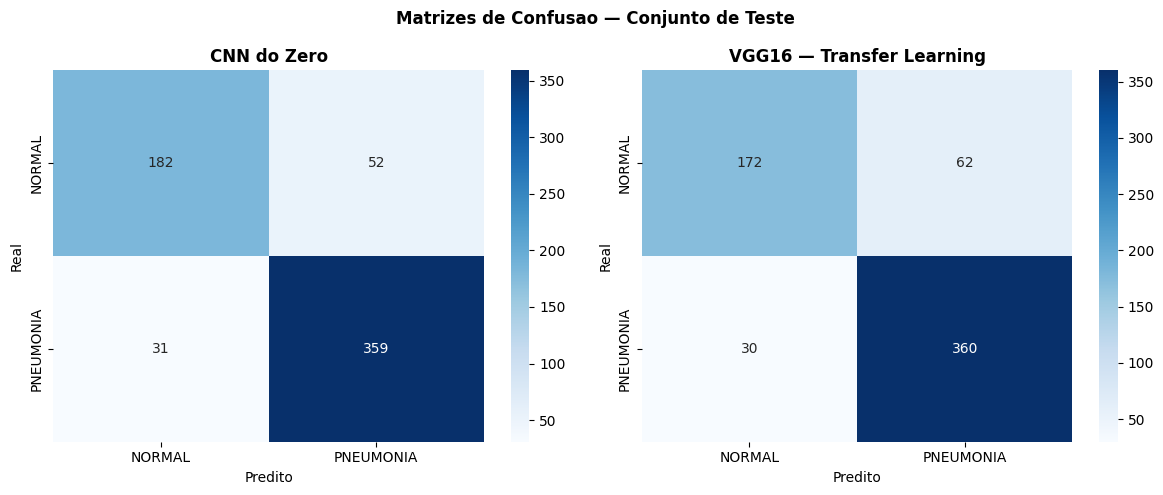

In [29]:
# Matrizes de confusao
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
titulos = ['CNN do Zero', 'VGG16 — Transfer Learning']
matrizes = [cm_zero, cm_vgg]

for ax, cm, titulo in zip(axes, matrizes, titulos):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['NORMAL', 'PNEUMONIA'],
        yticklabels=['NORMAL', 'PNEUMONIA']
    )
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.suptitle('Matrizes de Confusao — Conjunto de Teste', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Tabela comparativa de metricas
from sklearn.metrics import precision_score, recall_score

def metricas_resumo(y_true, y_pred, nome):
    return {
        'Modelo': nome,
        'Acuracia': round(accuracy_score(y_true, y_pred), 4),
        'Precisao': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1-Score': round(f1_score(y_true, y_pred), 4)
    }

import pandas as pd
df_metricas = pd.DataFrame([
    metricas_resumo(y_true_zero, y_pred_zero, 'CNN do Zero'),
    metricas_resumo(y_true_vgg, y_pred_vgg, 'VGG16 Transfer Learning')
])
df_metricas = df_metricas.set_index('Modelo')
print('Comparativo de Metricas — Conjunto de Teste')
print(df_metricas.to_string())

Comparativo de Metricas — Conjunto de Teste
                         Acuracia  Precisao  Recall  F1-Score
Modelo                                                       
CNN do Zero                0.8670    0.8735  0.9205    0.8964
VGG16 Transfer Learning    0.8526    0.8531  0.9231    0.8867


## 7. Prototipo de Interface — Classificacao Interativa

A celula abaixo permite fazer upload de uma imagem de raio-X e obter a predicao do modelo VGG16, simulando o uso do assistente cardiologico virtual.

Faca upload de uma imagem de raio-X (.jpg ou .png):


Saving P.png to P.png


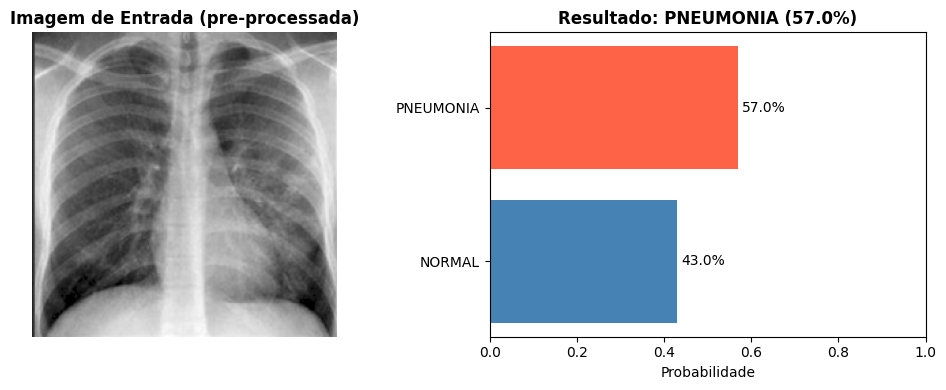

Arquivo: P.png
Classificacao: PNEUMONIA
Confianca: 56.97%
Nota: Este prototipo e de uso academico e nao substitui avaliacao medica profissional.


In [35]:
from google.colab import files
import cv2

print('Faca upload de uma imagem de raio-X (.jpg ou .png):')
uploaded = files.upload()

for nome_arquivo in uploaded.keys():
    # Pre-processamento
    img = cv2.imread(nome_arquivo, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    img_rgb = np.stack([img, img, img], axis=-1)
    img_input = np.expand_dims(img_rgb, axis=0)

    # Predicao
    prob = modelo_vgg.predict(img_input, verbose=0)[0][0]
    classe_predita = 'PNEUMONIA' if prob > 0.5 else 'NORMAL'
    confianca = prob if prob > 0.5 else 1 - prob

    # Exibicao
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(img_rgb[:, :, 0], cmap='gray')
    axes[0].set_title('Imagem de Entrada (pre-processada)', fontweight='bold')
    axes[0].axis('off')

    barras = axes[1].barh(
        ['NORMAL', 'PNEUMONIA'],
        [1 - prob, prob],
        color=['steelblue', 'tomato']
    )
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Probabilidade')
    axes[1].set_title(
        f'Resultado: {classe_predita} ({confianca:.1%})',
        fontweight='bold'
    )
    for bar, val in zip(barras, [1 - prob, prob]):
        axes[1].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                     f'{val:.1%}', va='center')

    plt.tight_layout()
    plt.show()

    print(f'Arquivo: {nome_arquivo}')
    print(f'Classificacao: {classe_predita}')
    print(f'Confianca: {confianca:.2%}')
    print('Nota: Este prototipo e de uso academico e nao substitui avaliacao medica profissional.')

## 8. Consideracoes Finais

Os dois modelos foram treinados e avaliados sobre o mesmo conjunto de teste. O Transfer Learning com VGG16 tende a apresentar melhor desempenho, especialmente em recall, por aproveitar representacoes visuais pre-aprendidas em larga escala.

O desbalanceamento entre as classes (mais imagens de Pneumonia no treino) pode inflar metricas de acuracia — por isso o F1-Score e o Recall sao as metricas mais relevantes para este contexto clinico, onde falsos negativos (nao detectar pneumonia existente) sao mais criticos que falsos positivos.

O prototipo de interface da Secao 7 demonstra, de forma simplificada, como o modelo poderia ser integrado em uma aplicacao de apoio ao diagnostico.

---

## Referencias

- Mooney, P. (2018). *Chest X-Ray Images (Pneumonia)*. Kaggle. https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
- Kermany, D. et al. (2018). *Identifying Medical Diagnoses and Treatable Diseases by Image-Based Deep Learning*. Cell, 172(5), 1122-1131.
- Simonyan, K., Zisserman, A. (2014). *Very Deep Convolutional Networks for Large-Scale Image Recognition*. arXiv:1409.1556.